<a href="https://colab.research.google.com/github/kebin7942/Python-Game/blob/main/7%EC%9B%94_6%EC%9D%BC_%EB%B3%B5%EC%8A%B5%EB%AC%B8%EC%A0%9C_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. 도형의 윤곽선을 검출해보세요.
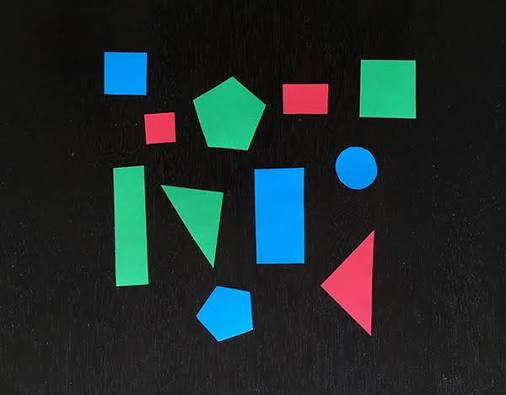

- 윤곽선을 검출한 후, 각각의 도형 이름이 표시되도록 만들어보세요.

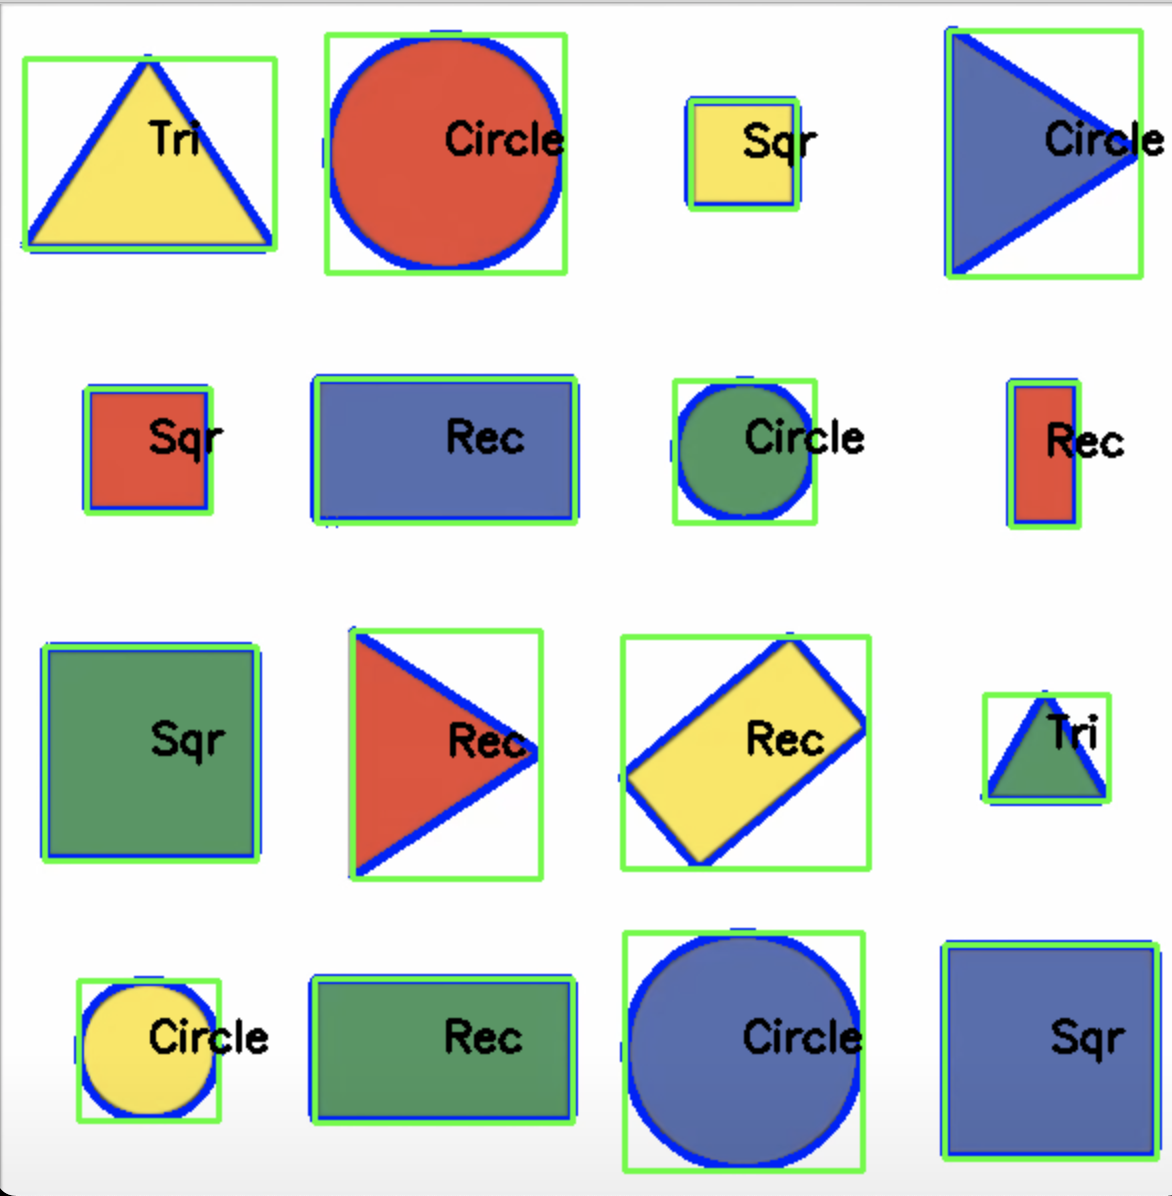

## 2. 윤곽선을 찾은 도형의 '넓이'를 계산해보세요.

Shape: Triangle, Area: 10000.0, Centroid: (200, 366)
Shape: Circle, Area: 7704.0, Centroid: (300, 100)
Shape: Rectangle, Area: 10000.0, Centroid: (100, 100)


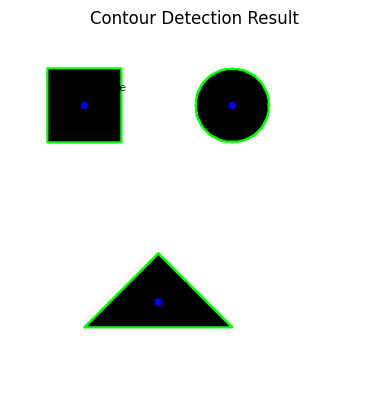

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 예시 이미지 생성 (실제 이미지가 있다면 cv2.imread('patterns.jpg')를 사용하세요)
img = np.zeros((500, 500, 3), dtype="uint8") + 255
cv2.rectangle(img, (50, 50), (150, 150), (0, 0, 0), -1)  # 사각형
cv2.circle(img, (300, 100), 50, (0, 0, 0), -1)          # 원
pts = np.array([[100, 400], [200, 300], [300, 400]], np.int32)
cv2.fillPoly(img, [pts], (0, 0, 0))                      # 삼각형

# 그레이스케일 변환 및 이진화
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# 윤곽선 검출
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    # 2. 넓이 계산
    area = cv2.contourArea(cnt)

    # 3. 무게중심 계산 (Moments 사용)
    M = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = 0, 0

    # 도형 판별 (근사화 사용)
    approx = cv2.approxPolyDP(cnt, 0.01 * cv2.arcLength(cnt, True), True)
    if len(approx) == 3:
        shape_name = "Triangle"
    elif len(approx) == 4:
        shape_name = "Rectangle"
    else:
        shape_name = "Circle"

    # 결과 그리기
    cv2.drawContours(img, [cnt], -1, (0, 255, 0), 2)
    cv2.circle(img, (cx, cy), 5, (255, 0, 0), -1)
    cv2.putText(img, f"{shape_name}", (cx - 20, cy - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

    print(f"Shape: {shape_name}, Area: {area}, Centroid: ({cx}, {cy})")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Contour Detection Result")
plt.axis('off')
plt.show()

## 3. 윤곽선을 찾은 도형의 '무게중심' 을 찾아보세요.

검출된 총 도형 수: 1

[1] Rectangle  | 넓이: 198970.0 | 무게중심: (252, 197)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


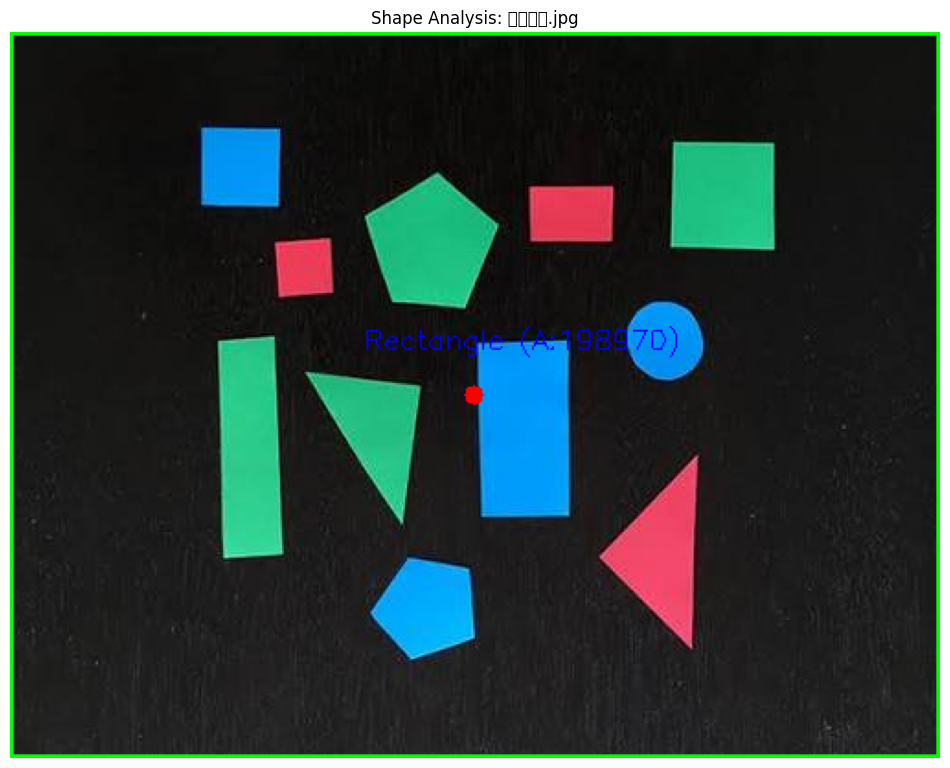

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 업로드된 '다운로드.jpg' 파일 불러오기
file_path = '/content/다운로드.jpg'

if not os.path.exists(file_path):
    print(f"에러: {file_path} 파일을 찾을 수 없습니다. 파일명을 확인해 주세요.")
else:
    img = cv2.imread(file_path)

    # 전처리: 그레이스케일 및 이진화
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # 이미지 특성에 따라 threshold 값을 조정해야 할 수 있습니다.
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

    # 윤곽선 검출
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 결과 시각화를 위한 이미지 복사
    result_img = img.copy()

    print(f"검출된 총 도형 수: {len(contours)}\n")

    for i, cnt in enumerate(contours):
        # 노이즈 제거를 위해 너무 작은 영역은 제외
        area = cv2.contourArea(cnt)
        if area < 100:
            continue

        # 무게중심 계산
        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
        else:
            cx, cy = 0, 0

        # 도형 판별 (근사화)
        approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)
        if len(approx) == 3:
            shape_name = "Triangle"
        elif len(approx) == 4:
            shape_name = "Rectangle"
        else:
            shape_name = "Circle"

        # 시각화 추가
        cv2.drawContours(result_img, [cnt], -1, (0, 255, 0), 2)
        cv2.circle(result_img, (cx, cy), 5, (0, 0, 255), -1)
        info_text = f"{shape_name} (A:{int(area)})"
        cv2.putText(result_img, info_text, (cx - 60, cy - 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        print(f"[{i+1}] {shape_name:10} | 넓이: {area:8.1f} | 무게중심: ({cx}, {cy})")

    # 최종 결과 출력
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title("Shape Analysis: 다운로드.jpg")
    plt.axis('off')
    plt.show()

[1] Polygon    | 넓이:   2192.5 | 중심: (226, 312)
[2] Triangle   | 넓이:   2704.0 | 중심: (354, 283)
[3] Triangle   | 넓이:   2434.0 | 중심: (198, 215)
[4] Rectangle  | 넓이:   4571.0 | 중심: (279, 215)
[5] Rectangle  | 넓이:   3701.0 | 중심: (129, 226)
[6] Polygon    | 넓이:   1356.0 | 중심: (355, 167)
[7] Rectangle  | 넓이:    852.5 | 중심: (159, 127)
[8] Rectangle  | 넓이:   1283.0 | 중심: (305, 98)
[9] Polygon    | 넓이:   3522.5 | 중심: (228, 114)
[10] Rectangle  | 넓이:   3153.5 | 중심: (387, 88)
[11] Rectangle  | 넓이:   1760.5 | 중심: (125, 72)


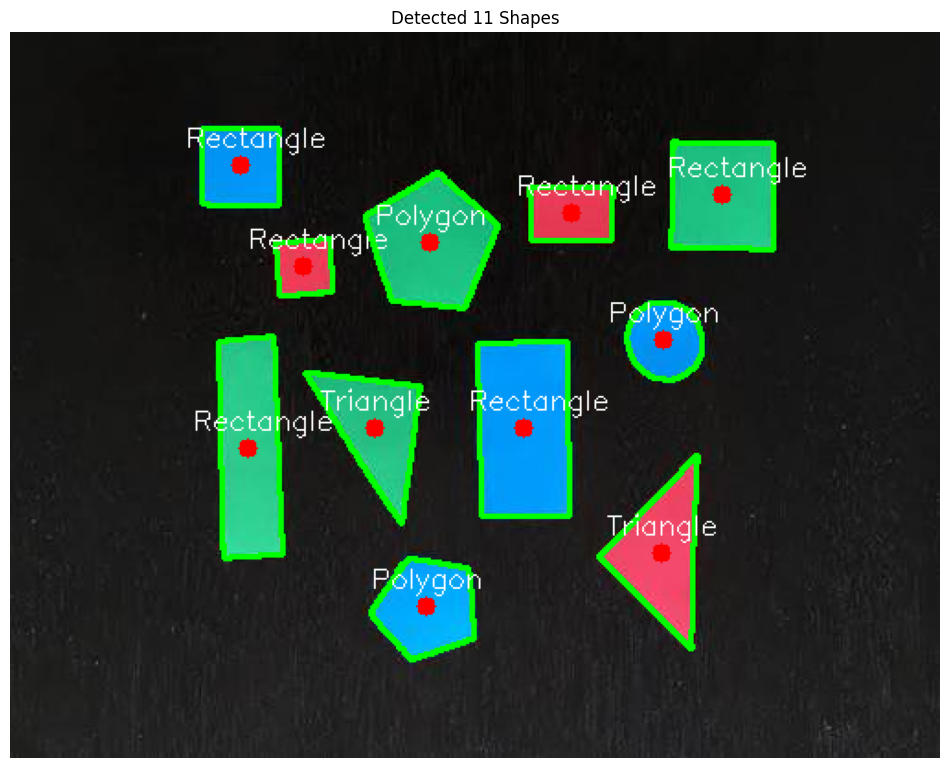

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

file_path = '/content/다운로드.jpg'

if not os.path.exists(file_path):
    print(f'에러: {file_path} 파일을 찾을 수 없습니다.')
else:
    img = cv2.imread(file_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 검은색 배경의 경우, 밝은 부분(도형)을 추출하기 위해 THRESH_BINARY 사용
    # 이미지의 밝기에 따라 50~100 사이로 조정 가능합니다.
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

    # RETR_LIST를 사용하여 계층 구조에 상관없이 모든 윤곽선을 찾습니다.
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    result_img = img.copy()
    count = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        # 너무 작은 노이즈나 이미지 전체 크기와 비슷한 외곽선은 제외
        if area < 500 or area > (img.shape[0] * img.shape[1] * 0.9):
            continue

        count += 1
        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
        else:
            cx, cy = 0, 0

        # 도형 판별
        approx = cv2.approxPolyDP(cnt, 0.03 * cv2.arcLength(cnt, True), True)
        if len(approx) == 3:
            shape_name = 'Triangle'
        elif len(approx) == 4:
            shape_name = 'Rectangle'
        elif len(approx) > 4 and len(approx) < 10:
            shape_name = 'Polygon'
        else:
            shape_name = 'Circle'

        cv2.drawContours(result_img, [cnt], -1, (0, 255, 0), 2)
        cv2.circle(result_img, (cx, cy), 5, (0, 0, 255), -1)
        cv2.putText(result_img, shape_name, (cx - 30, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        print(f'[{count}] {shape_name:10} | 넓이: {area:8.1f} | 중심: ({cx}, {cy})')

    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title(f'Detected {count} Shapes')
    plt.axis('off')
    plt.show()

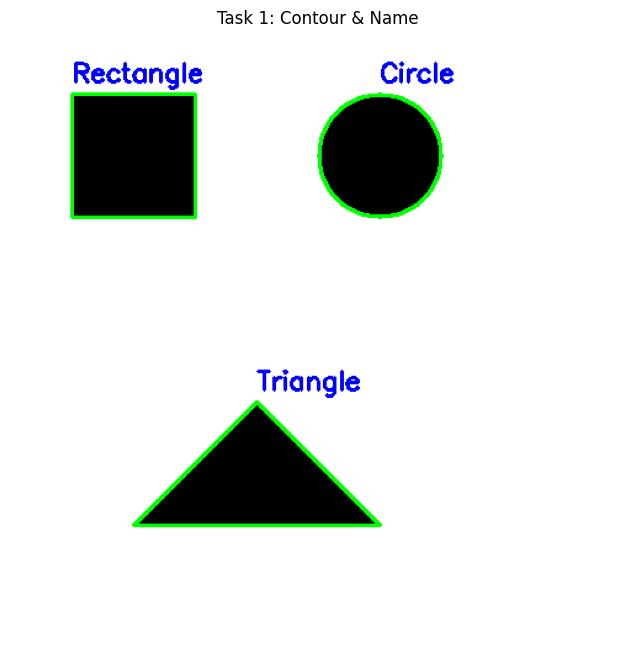

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 생성 (또는 cv2.imread('patterns.jpg'))
img = np.zeros((500, 500, 3), dtype="uint8") + 255
cv2.rectangle(img, (50, 50), (150, 150), (0, 0, 0), -1)
cv2.circle(img, (300, 100), 50, (0, 0, 0), -1)
pts = np.array([[100, 400], [200, 300], [300, 400]], np.int32)
cv2.fillPoly(img, [pts], (0, 0, 0))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# 윤곽선 검출
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    # 도형 판별을 위한 근사화
    approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)

    # 좌표 계산 (텍스트 표시용)
    x, y = cnt[0][0]

    if len(approx) == 3:
        shape_name = "Triangle"
    elif len(approx) == 4:
        shape_name = "Rectangle"
    else:
        shape_name = "Circle"

    # 윤곽선 그리기 및 이름 표시
    cv2.drawContours(img, [cnt], -1, (0, 255, 0), 2)
    cv2.putText(img, shape_name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Task 1: Contour & Name")
plt.axis('off')
plt.show()